<a href="https://colab.research.google.com/github/fur-ruf/data_analysis/blob/main/lab1_mashine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №1
## Работа с данными

Выполнила: Будюкова Полина (408326)

Группа: P3321

Преподаватель: Солодкая Мария Александровна

### Цель работы:

Провести очистку набора данных и отобрать признаки.

### Задание:
1. Удалить строки, где обе целевых переменные пустые.
2. Пропуски заполнить NaN.
3. Сохранить названия признаков.
4. Построить гистограмму важности признаков по критерию gain_ratio (нормированный прирост информации).
5. Построить тепловую карту признаков (матрица корреляций всех признаков со всеми, в том числе целевыми
переменными), для удобства коэффициент корреляции берите по модулю.
6. Для каждого признака построить график распределения с отложенными на нем линиями первого и третьего квартилей.
7. Для каждого признака посчитать элементы описательной статистики.

На основании всего этого составить список удаляемых и оставляемых признаков с обоснованием, почему вы это сделали.

Борьба с выбросами и заполнение пропусков остается на усмотрение студента, но должна быть обоснована и проводится только после расчета корреляций и важности.

Нормализация в данной лабораторной не предполагается.

## Ход работы

Загрузка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'sample_data/ID_data_mass_18122012.csv'
df = pd.read_csv(file_path)
df_raw = df

Приведение таблиц в удобный вид (объединяем заголовки)

In [ ]:
headers = []
for col in range(df_raw.shape[1]):
    l1 = str(df_raw.iloc[0, col]) if pd.notna(df_raw.iloc[0, col]) else ''
    l2 = str(df_raw.iloc[1, col]) if pd.notna(df_raw.iloc[1, col]) else ''

    if l1 and l2:
        header = f"{l1}_{l2}"
    elif l1:
        header = l1
    elif l2:
        header = l2
    else:
        header = f"Unnamed_{col}"

    headers.append(header)

df = df_raw.iloc[2:].copy()
df.columns = headers
df = df.reset_index(drop=True)

Объединение колонок КГФ (переводим т/тыс.м3 в г/м3)

In [ ]:
last_cols = df.columns[-2:].tolist()
col_g_m3, col_t_m3 = last_cols

df[col_g_m3] = pd.to_numeric(df[col_g_m3].astype(str).str.replace(',', '.'), errors='coerce')
df[col_t_m3] = pd.to_numeric(df[col_t_m3].astype(str).str.replace(',', '.'), errors='coerce')

df['КГФ_г/м3_общий'] = df[col_g_m3].fillna(df[col_t_m3] * 1000)

print(f"Найдено значений в {col_g_m3}: {df[col_g_m3].notna().sum()}")
print(f"Найдено значений в {col_t_m3}: {df[col_t_m3].notna().sum()}")
print(f"Итоговых значений: {df['КГФ_г/м3_общий'].notna().sum()}")

df = df.drop(columns=last_cols)

# print("\nДанные после обработки заголовков:")
# display(df.head())

Найдено значений в КГФ_г/м3: 23
Найдено значений в КГФ_т/тыс.м3: 70
Итоговых значений: 93


Удаляем строки, где обе целевые переменные пусты

In [ ]:
targets = ['G_total_кг/с', 'КГФ_г/м3_общий']

df = df.dropna(subset=targets, how='all').reset_index(drop=True)

Дату в день, месяц, год

In [ ]:
df['дд.мм.гггг'] = df['дд.мм.гггг'].str.strip()
df['дд.мм.гггг'] = df['дд.мм.гггг'].str.replace('/', '.', regex=False)
df['дд.мм.гггг'] = pd.to_datetime(df['дд.мм.гггг'], format='%d.%m.%y', errors='coerce')

df['День'] = df['дд.мм.гггг'].dt.day
df['Месяц'] = df['дд.мм.гггг'].dt.month
df['Год'] = df['дд.мм.гггг'].dt.year
df = df.drop(columns=['дд.мм.гггг'])

df.head()
# df.dtypes

,№,Глубина манометра_м,Dшт_мм,Руст_бара,Рзаб_бара,Pлин_бара,Руст_бар,Рзаб_бар,Рлин_бар,Туст_ С,...,Pсб_ бар,Ro_g_кг/м3,Ro_c_кг/м3,Ro_w_кг/м3,Удельная плотность газа _б/р,G_total_кг/с,КГФ_г/м3_общий,День,Месяц,Год
0,804,"3576,30","7,94","249,60","370,10","101,80","249,00","359,60","101,80","53,00",...,"92,38","0,8060","801,0","1000,0","0,6694","2,78",311.91,5,6,2008
1,804,"3576,30","9,53","233,50","364,60","101,30","231,00","338,10","102,40","58,80",...,"91,69","0,8060","801,0","1000,0","0,6694","3,70",288.60,6,6,2008
2,804,"3576,30","11,11","213,40","357,10","101,60","211,00","314,80","100,60","63,60",...,"90,20","0,8060","801,0","1000,0","0,6694","4,52",248.79,7,6,2008
3,804,"3576,30","12,70","191,60","347,40","98,40","187,00","291,50","99,00","64,70",...,"88,03","0,8060","801,0","1000,0","0,6694","5,22",223.56,8,6,2008
4,804,"3576,30","14,29","171,90","337,70","99,20","169,00","270,30","99,50","64,00",...,"88,53","0,8060","801,0","1000,0","0,6694","5,77",215.15,9,6,2008


Переводим всё в числовые значения. Пропуски заполняем NaN

In [ ]:
print(df.columns[df.columns.duplicated()])

df = df.loc[:, ~df.columns.duplicated()]

for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.head()

Index(['Дебит воды_м3/сут'], dtype='object')


,№,Глубина манометра_м,Dшт_мм,Руст_бара,Рзаб_бара,Pлин_бара,Руст_бар,Рзаб_бар,Рлин_бар,Туст_ С,...,Pсб_ бар,Ro_g_кг/м3,Ro_c_кг/м3,Ro_w_кг/м3,Удельная плотность газа _б/р,G_total_кг/с,КГФ_г/м3_общий,День,Месяц,Год
0,804,3576.3,7.94,249.6,370.1,101.8,249.0,359.6,101.8,53.0,...,92.38,0.806,801.0,1000.0,0.6694,2.78,311.91,5,6,2008
1,804,3576.3,9.53,233.5,364.6,101.3,231.0,338.1,102.4,58.8,...,91.69,0.806,801.0,1000.0,0.6694,3.70,288.60,6,6,2008
2,804,3576.3,11.11,213.4,357.1,101.6,211.0,314.8,100.6,63.6,...,90.20,0.806,801.0,1000.0,0.6694,4.52,248.79,7,6,2008
3,804,3576.3,12.70,191.6,347.4,98.4,187.0,291.5,99.0,64.7,...,88.03,0.806,801.0,1000.0,0.6694,5.22,223.56,8,6,2008
4,804,3576.3,14.29,171.9,337.7,99.2,169.0,270.3,99.5,64.0,...,88.53,0.806,801.0,1000.0,0.6694,5.77,215.15,9,6,2008


Гистограмма важности признаков по критерию gain_ratio (нормированный прирост информации).


=== Важность относительно G_total_кг/с ===



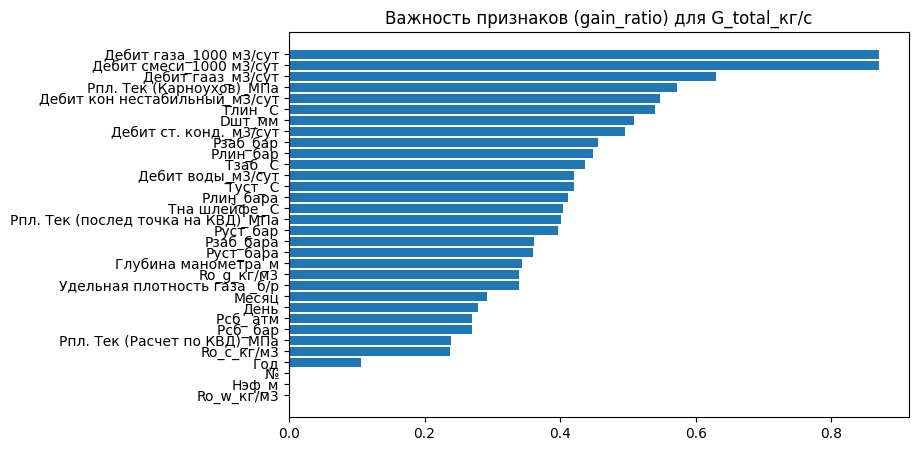


=== Важность относительно КГФ_г/м3_общий ===



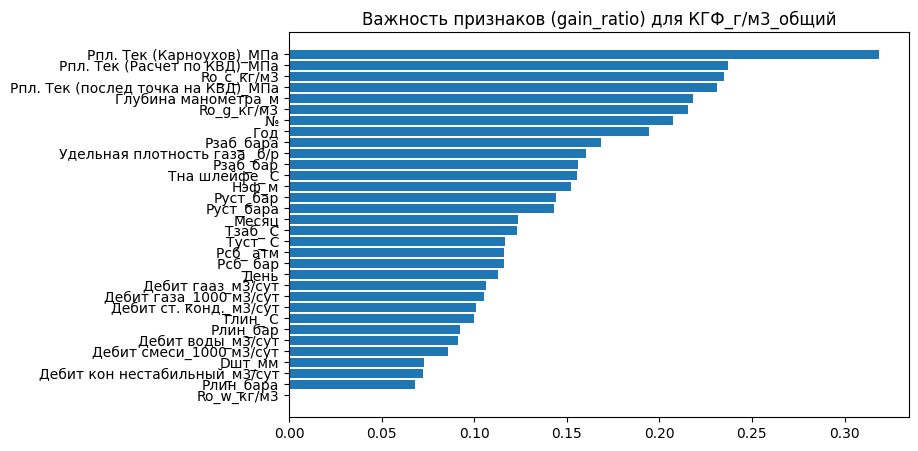

In [ ]:
def entropy(s):
    p = s.value_counts(normalize=True)
    return -sum(p * np.log2(p + 1e-9))

def gain_ratio(feature, target, bins=5):
    f_binned = pd.qcut(feature, q=bins, duplicates='drop')
    t_binned = pd.qcut(target, q=bins, duplicates='drop')

    total_entropy = entropy(t_binned)
    e_cond = 0
    intrinsic_value = 0

    for val, idx in f_binned.groupby(f_binned, observed=True):
        p = len(idx) / len(feature)
        e_cond += p * entropy(t_binned[idx.index])
        intrinsic_value -= p * np.log2(p + 1e-9)

    info_gain = total_entropy - e_cond
    return info_gain / intrinsic_value if intrinsic_value != 0 else 0

importance_dict = {}

for target in targets:
    print(f"\n=== Важность относительно {target} ===\n")

    features = df.drop(columns=targets)
    importance = {}

    for col in features.columns:
        if pd.api.types.is_numeric_dtype(features[col]):
            valid = features[col].notna() & df[target].notna()
            if valid.sum() < 10:
                continue

            X = features.loc[valid, col]
            y = df.loc[valid, target]
            importance[col] = gain_ratio(X, y)

    importance = dict(sorted(importance.items(), key=lambda x: x[1], reverse=True))
    importance_dict[target] = importance

    plt.figure(figsize=(8,5))
    plt.barh(list(importance.keys()), list(importance.values()))
    plt.title(f"Важность признаков (gain_ratio) для {target}")
    plt.gca().invert_yaxis()
    plt.show()

Построить тепловую карту признаков (матрица корреляций всех признаков со всеми, в том числе целевыми
переменными).

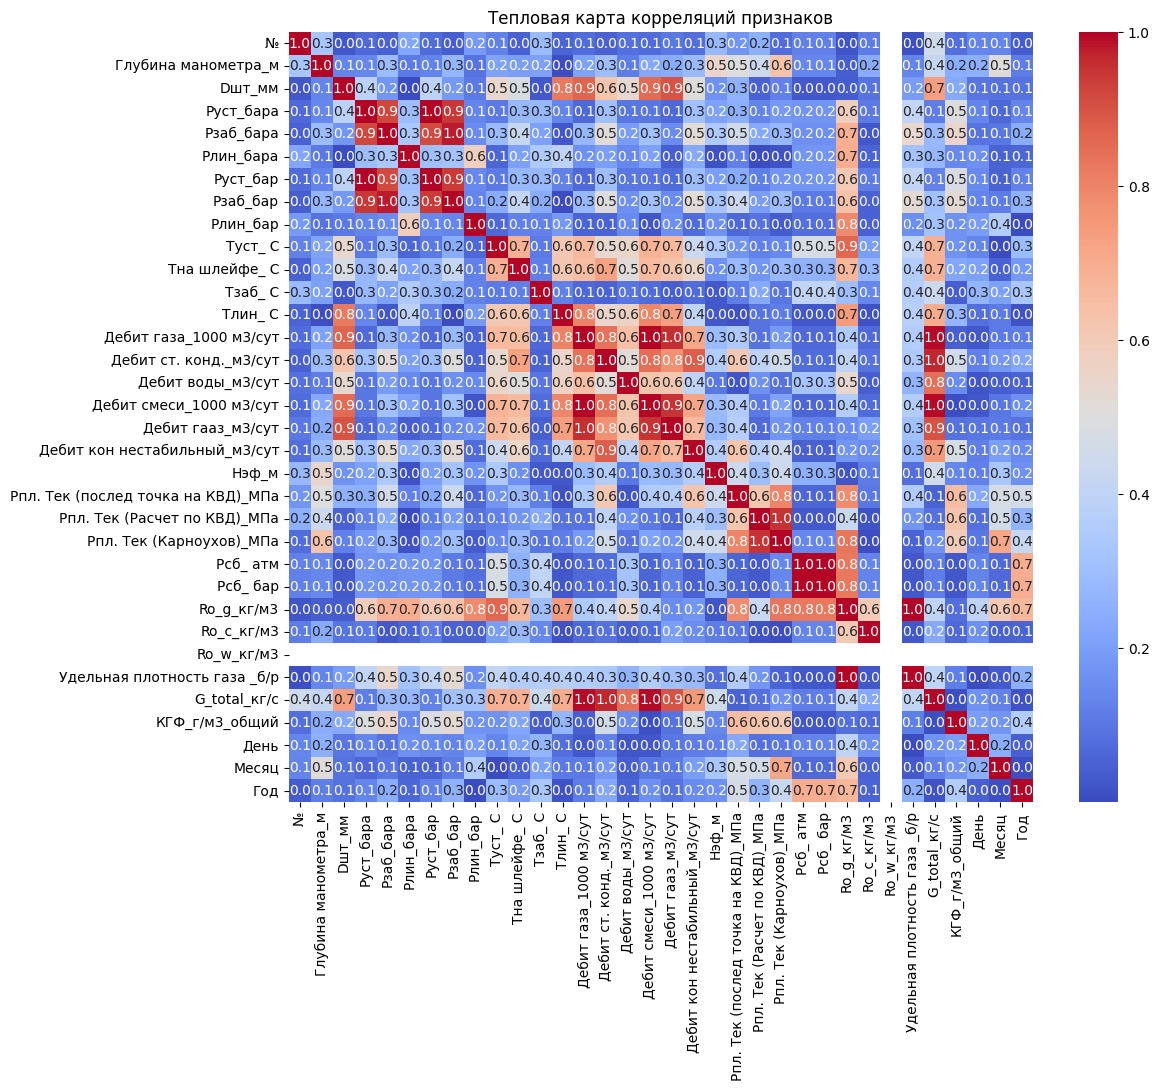

In [ ]:
corr_matrix = df.corr().abs()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap='coolwarm', cbar=True)

plt.title("Тепловая карта корреляций признаков")
plt.show()

Для каждого признака построить график распределения с отложенными на нем линиями первого и третьего квартилей.

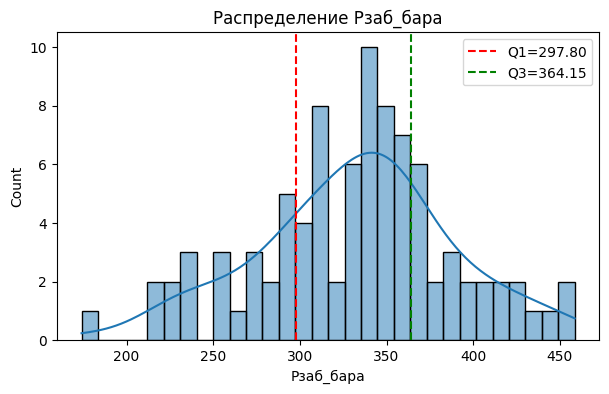

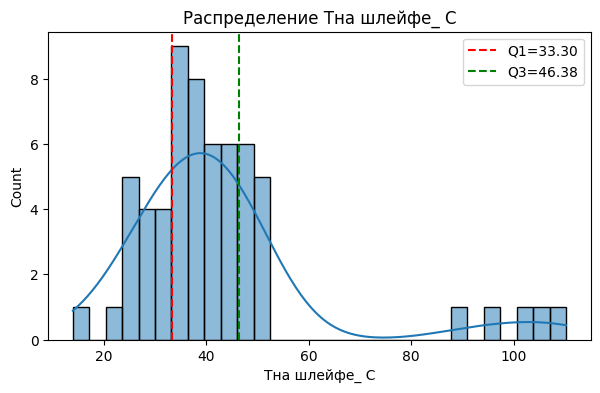

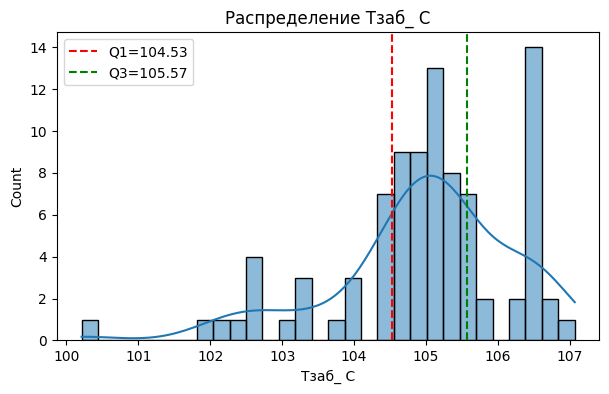

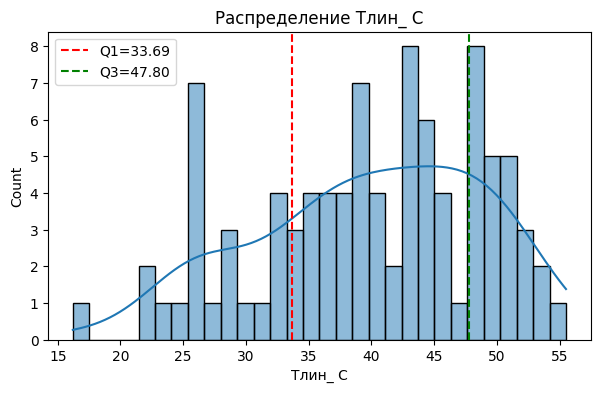

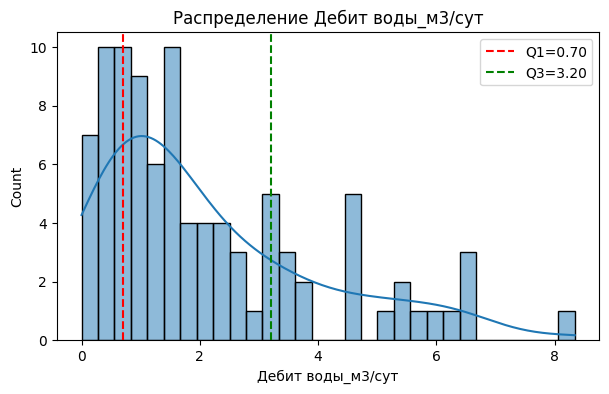

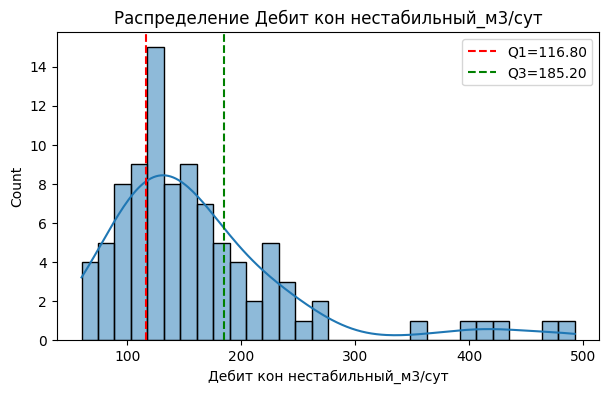

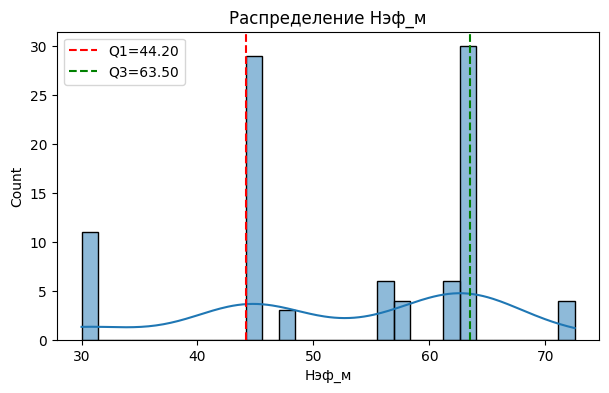

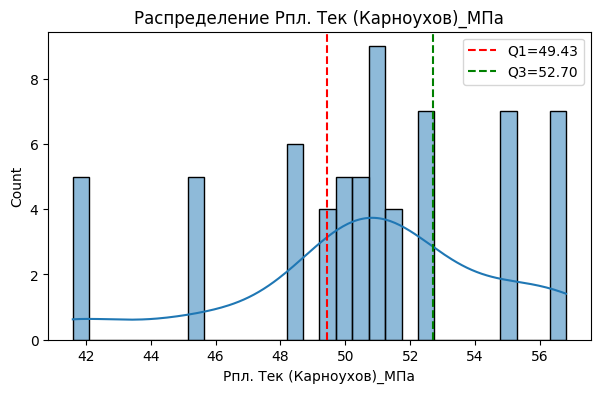

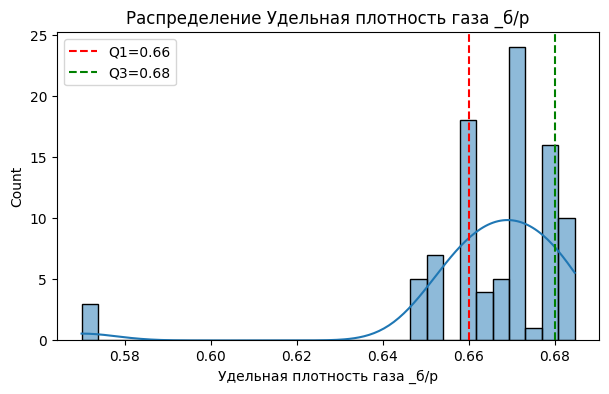

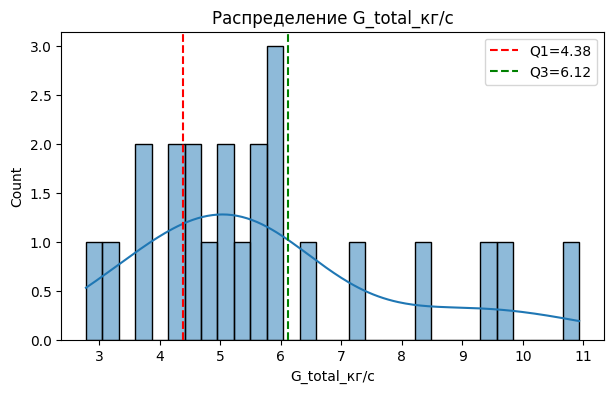

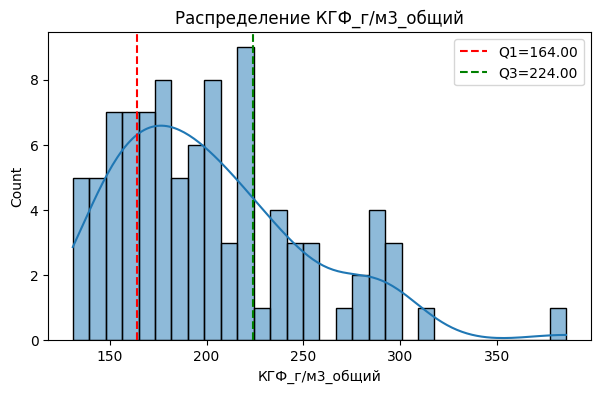

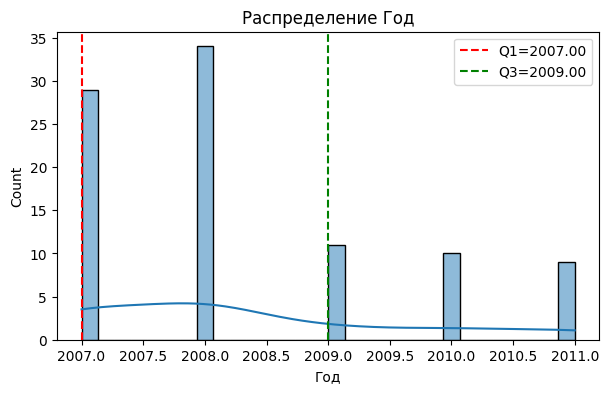

In [ ]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        plt.figure(figsize=(7,4))
        sns.histplot(df[col].dropna(), kde=True, bins=30)

        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)

        plt.axvline(q1, color='red', linestyle='--', label=f'Q1={q1:.2f}')
        plt.axvline(q3, color='green', linestyle='--', label=f'Q3={q3:.2f}')

        plt.title(f"Распределение {col}")
        plt.legend()
        plt.show()

Для каждого признака посчитать элементы описательной статистики.


In [ ]:
stats = df.describe().T
stats['median'] = df.median()
stats['variance'] = df.var()
stats['skew'] = df.skew()

stats = stats[['count','mean','median','std','variance','min','25%','50%','75%','max','skew']]
stats.round(3)

,count,mean,median,std,variance,min,25%,50%,75%,max,skew
№,93.0,18004.151,21203.000,7918.038,6.269532e+07,804.000,20503.000,21203.000,22501.000,22503.000,-1.730
Глубина манометра_м,90.0,3524.087,3579.000,144.475,2.087299e+04,3276.000,3427.625,3579.000,3652.250,3670.000,-0.706
Dшт_мм,93.0,10.951,11.110,2.423,5.872000e+00,6.350,9.530,11.110,12.700,15.880,0.006
Руст_бара,93.0,228.294,229.890,41.897,1.755363e+03,138.160,201.640,229.890,252.000,337.110,0.045
Рзаб_бара,90.0,331.762,337.790,56.481,3.190129e+03,174.000,297.798,337.790,364.150,458.600,-0.195
Pлин_бара,93.0,99.861,100.800,7.301,5.330000e+01,73.310,95.950,100.800,103.870,121.680,-0.917
Руст_бар,93.0,227.645,228.000,41.757,1.743669e+03,136.000,200.000,228.000,252.000,333.000,0.001
Рзаб_бар,90.0,330.334,334.250,56.357,3.176167e+03,174.000,294.625,334.250,362.150,458.500,-0.101
Рлин_бар,93.0,98.005,100.260,12.426,1.543970e+02,40.740,95.340,100.260,104.000,123.620,-2.674
Туст_ С,93.0,56.172,58.000,11.251,1.265800e+02,24.200,50.300,58.000,64.000,75.000,-0.833


Мало значений:

*   Ro_g_кг/м3
*   Ro_w_кг/м3

Низкая или слишком высокая корреляция с целевыми переменными:

Низкая:

*   Pлин_бара
*   Pлин_бар
*   Pсб_атм
*   Pсб_бар
*   Ro_c_кг/м3
*   День
*   Месяц
*   Глубина манометра_м

Высокая (1):

*   Дебит газа_1000 м3/сут
*   Дебит ст. конд._м3/сут
*   Дебит смеси_1000 м3/сут

Сильная корреляция между признаками:

*   Руст_бара
*   Pзаб_бар
*   Руст_бар
*   Дебит газа_1000 м3/сут (+ высокая с целевой)
*   Dшт_мм
*   Рпл. Тек (Расчет по КВД)_МПа
*   Рпл. Тек (послед точка на КВД)_МПа
*   Туст_ С






In [ ]:
df = df.drop(columns=["№"])

In [ ]:
df = df.drop(columns=["Ro_g_кг/м3", "Ro_w_кг/м3"])

In [ ]:
df = df.drop(columns=["Глубина манометра_м", "День", "Месяц", "Pсб_ бар", "Pсб_ атм", "Ro_c_кг/м3", "Рлин_бар", "Pлин_бара"])

In [ ]:
df = df.drop(columns=['Дебит газа_1000 м3/сут', 'Дебит ст. конд._м3/сут', 'Дебит смеси_1000 м3/сут'])

In [ ]:
df = df.drop(columns=["Рпл. Тек (Расчет по КВД)_МПа", "Рпл. Тек (послед точка на КВД)_МПа", "Туст_ С", "Руст_бара", "Рзаб_бар", "Руст_бар", "Дебит гааз_м3/сут", "Dшт_мм"])

Выбросы

In [ ]:
skewness = df.skew() # показатель ассиметрии
print(skewness)

Рзаб_бара                       -0.195183
Тна шлейфе_ С                    2.203984
Тзаб_ С                         -1.059351
Tлин_ С                         -0.418091
Дебит воды_м3/сут                1.203074
Дебит кон нестабильный_м3/сут    1.988575
Нэф_м                           -0.436030
Рпл. Тек (Карноухов)_МПа        -0.618345
Удельная плотность газа _б/р    -3.460171
G_total_кг/с                     1.024358
КГФ_г/м3_общий                   0.984060
Год                              0.837428
dtype: float64


In [ ]:
def clean_outliers_and_fill(df):
    df_clean = df.copy()

    for col in df_clean.columns:
        if df_clean[col].dtype != 'float64' and df_clean[col].dtype != 'int64':
            continue

        skew = df_clean[col].skew()

        if abs(skew) < 0.5:
            mean = df_clean[col].mean()
            std = df_clean[col].std()
            lower = mean - 3 * std
            upper = mean + 3 * std
        else:
            Q1 = df_clean[col].quantile(0.25)
            Q3 = df_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

        df_clean[col] = df_clean[col].where(
            (df_clean[col] >= lower) & (df_clean[col] <= upper)
        )

        if abs(skew) < 0.5:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mean())
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    return df_clean